<a href="https://colab.research.google.com/github/sureshtonystrak/cab-fare-prediction/blob/main/Cab_Fare_pridiction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import seaborn as sns
from random import randrange, uniform


2

In [ ]:
Train_Data = pd.read_csv('/content/train_cab_fare.csv', nrows=500000, header=0)
if 'key' in Train_Data.columns:
    Train_Data = Train_Data.drop(columns=['key'])

3

In [ ]:
Train_Data.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1.0
1,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1.0
2,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2.0
3,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1.0
4,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1.0


4

In [ ]:
Train_Data['fare_amount']= Train_Data['fare_amount'].apply(pd.to_numeric,
errors='coerce')
Train_Data['fare_amount']= Train_Data['fare_amount'].replace({0:np.nan})
Train_Data['passenger_count']=Train_Data['passenger_count'].fillna(0)
Train_Data['passenger_count']= Train_Data['passenger_count'].astype(int)
Train_Data['passenger_count']=Train_Data['passenger_count'].replace({0:
np.nan})
Train_Data['pickup_longitude']= Train_Data['pickup_longitude'].replace({0:np.nan})
Train_Data['pickup_latitude']= Train_Data['pickup_latitude'].replace({0:np.nan})
Train_Data['dropoff_longitude']=Train_Data['dropoff_longitude'].replace({0:np.nan})
Train_Data['dropoff_latitude']= Train_Data['dropoff_latitude'].replace({0:np.nan})

5

In [ ]:
Train_Data['fare_amount']= Train_Data['fare_amount'].apply(pd.to_numeric,
errors='coerce')
Train_Data['fare_amount']= Train_Data['fare_amount'].replace({0:np.nan})
Train_Data['passenger_count']=Train_Data['passenger_count'].fillna(0)
Train_Data['passenger_count']= Train_Data['passenger_count'].astype(int)
Train_Data['passenger_count']=Train_Data['passenger_count'].replace({0:
np.nan})
Train_Data['pickup_longitude']= Train_Data['pickup_longitude'].replace({0:np.nan})
Train_Data['pickup_latitude']= Train_Data['pickup_latitude'].replace({0:np.nan})
Train_Data['dropoff_longitude']=Train_Data['dropoff_longitude'].replace({0:np.nan})
Train_Data['dropoff_latitude']= Train_Data['dropoff_latitude'].replace({0:np.nan})

6

In [ ]:
Train_Data.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1.0
1,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1.0
2,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2.0
3,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1.0
4,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1.0


7

In [ ]:
Train_Data.shape

(16067, 7)

8

In [ ]:
sns.set(style='darkgrid',palette='Set1')

9

<ipython-input-9-29d966f78318>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  _ = sns.distplot(Train_Data['fare_amount'],bins=50)
<ipython-input-9-29d966f78318>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  _ = sns.distplot(Train_Data['pickup_longitude'],bins=50)
<ipython-input-9-29d966f78318>:7: UserWarning: 

`dis

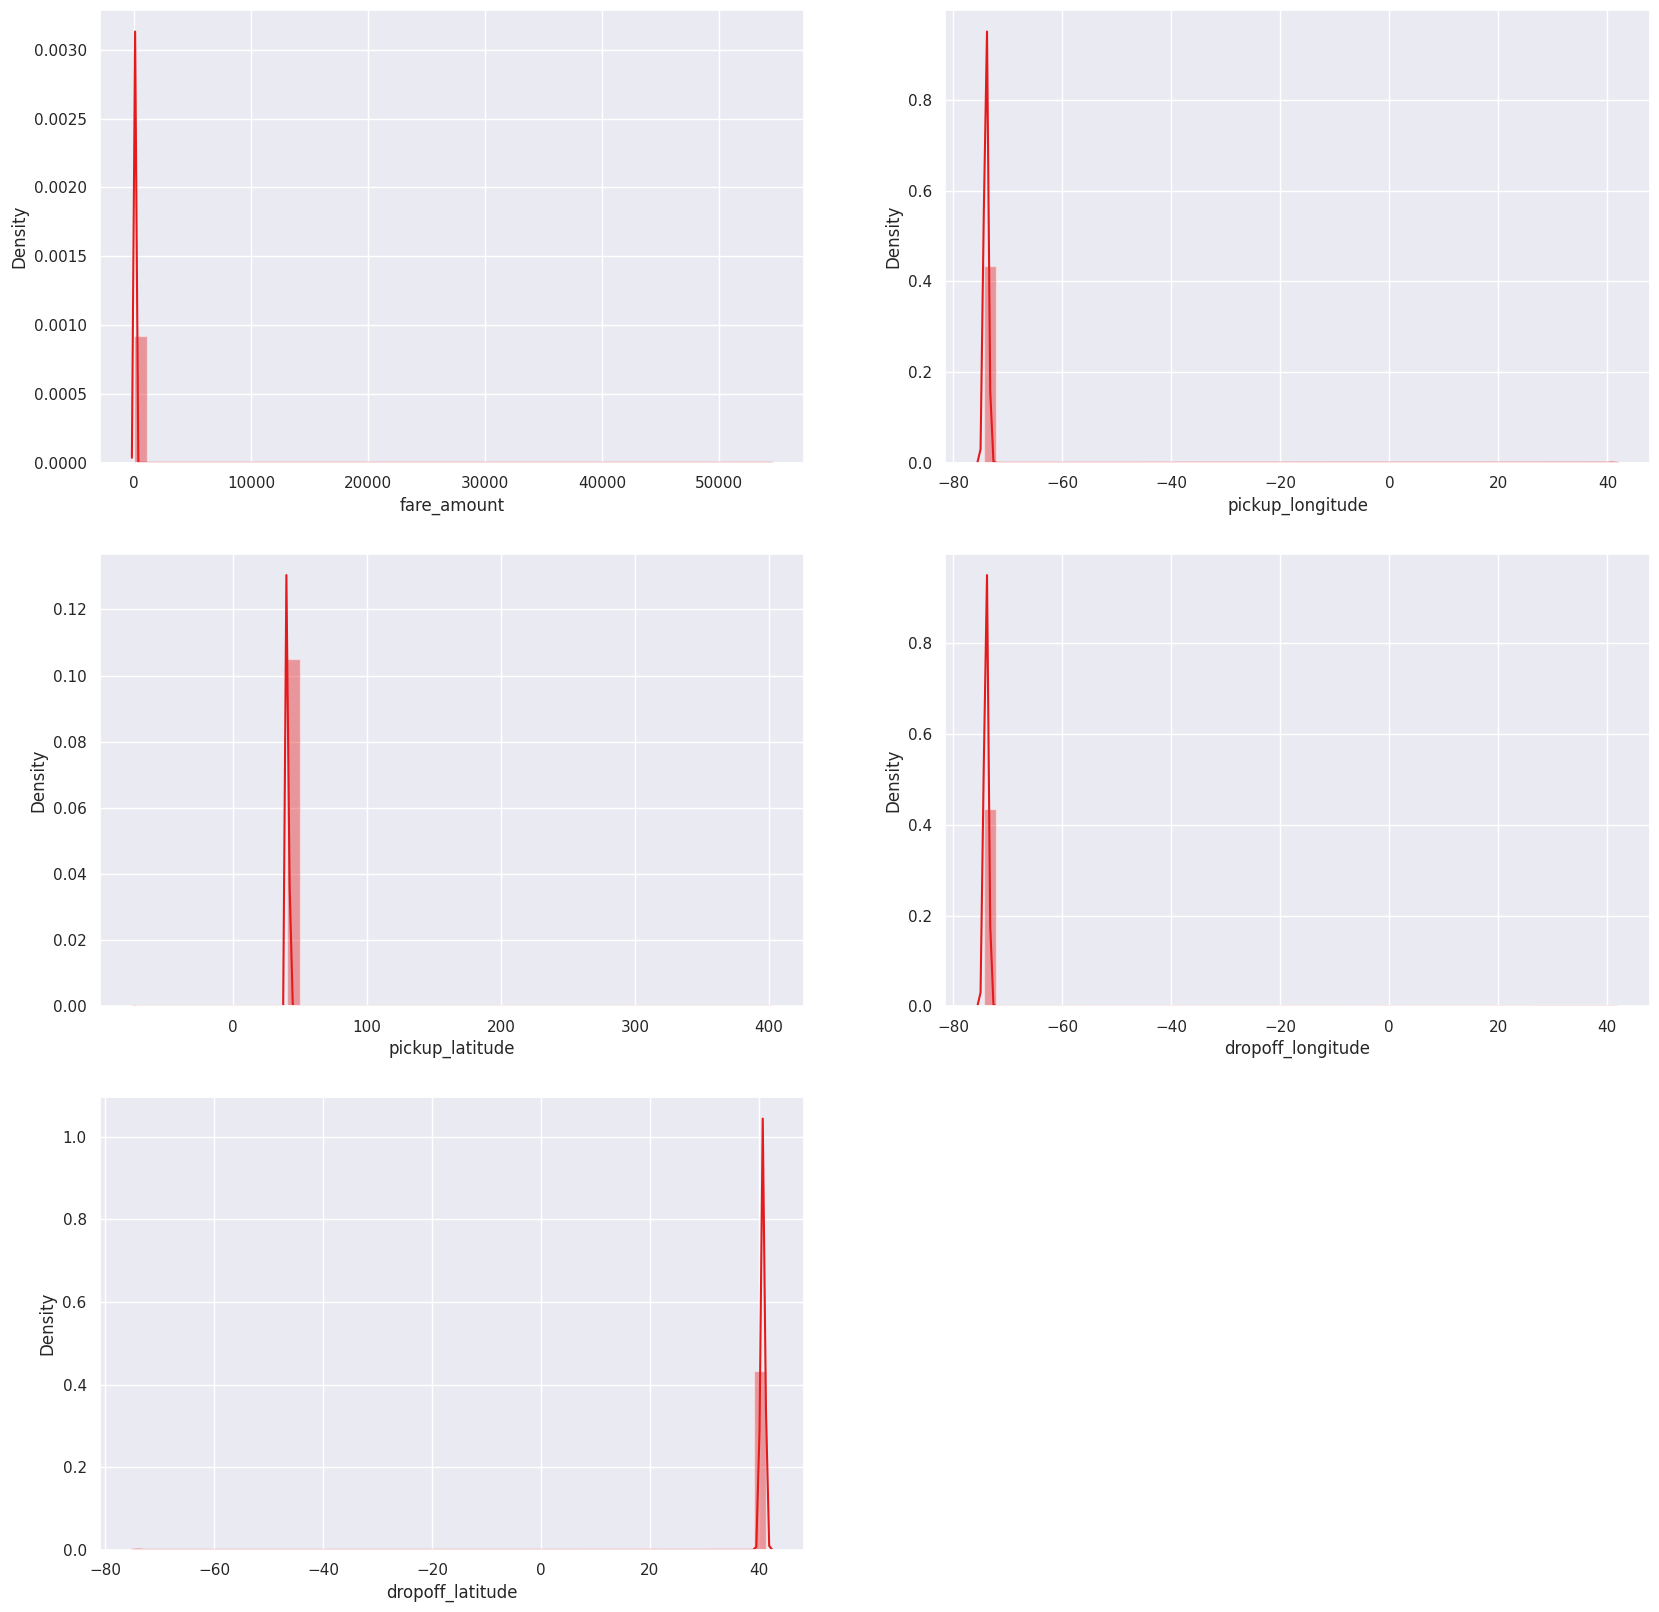

In [ ]:
plt.figure(figsize=(20,20))
plt.subplot(321)
_ = sns.distplot(Train_Data['fare_amount'],bins=50)
plt.subplot(322)
_ = sns.distplot(Train_Data['pickup_longitude'],bins=50)
plt.subplot(323)
_ = sns.distplot(Train_Data['pickup_latitude'],bins=50)
plt.subplot(324)
_ = sns.distplot(Train_Data['dropoff_longitude'],bins=50)
plt.subplot(325)
_ = sns.distplot(Train_Data['dropoff_latitude'],bins=50)
plt.show()

10. calculate missing values

In [ ]:
missing_val = pd.DataFrame(Train_Data.isnull().sum())

In [ ]:
missing_val = missing_val.reset_index()

In [ ]:
missing_val = missing_val.rename(columns = {'index': 'Variables', 0: 'count'})

In [ ]:
missing_val['Missing_percentage'] = (missing_val['count']/len(Train_Data)*100)

In [ ]:
missing_val = missing_val.sort_values('Missing_percentage', ascending =
False).reset_index(drop = True)
print(missing_val)

           Variables  count  Missing_percentage
0   pickup_longitude    315            1.960540
1    pickup_latitude    315            1.960540
2  dropoff_longitude    314            1.954316
3   dropoff_latitude    312            1.941868
4    passenger_count    113            0.703305
5        fare_amount     26            0.161822
6    pickup_datetime      0            0.000000


11

In [ ]:
Train_Data.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,16041.000000,15752.000000,15752.000000,15753.000000,15755.000000,15954.000000
mean,15.015940,-73.911859,40.712919,-73.906698,40.688014,2.634574
std,430.474347,2.651364,3.877557,2.702914,2.624540,60.954312
min,-3.000000,-74.438233,-74.006893,-74.429332,-74.006377,1.000000
25%,6.000000,-73.992386,40.736548,-73.991377,40.736258,1.000000
50%,8.500000,-73.982040,40.753299,-73.980567,40.754223,1.000000
75%,12.500000,-73.968079,40.767800,-73.965360,40.768311,2.000000
max,54343.000000,40.766125,401.083332,40.802437,41.366138,5345.000000


12

In [ ]:
Train_Data['fare_amount'] =Train_Data['fare_amount'].fillna(Train_Data['fare_amount'].mean())
Train_Data['pickup_longitude']=Train_Data['pickup_longitude'].fillna(Train_Data['pickup_longitude'].mean())
Train_Data['pickup_latitude']=Train_Data['pickup_latitude'].fillna(Train_Data['pickup_latitude'].mean())
Train_Data['dropoff_longitude']=Train_Data['dropoff_longitude'].fillna(Train_Data['dropoff_longitude'].mean())
Train_Data['dropoff_latitude']=Train_Data['dropoff_latitude'].fillna(Train_Data['dropoff_latitude'].mean())

In [ ]:
Train_Data['passenger_count'] =Train_Data['passenger_count'].fillna(int(Train_Data['passenger_count'].mode()))

<ipython-input-18-7bc7daa9b18c>:1: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  Train_Data['passenger_count'] =Train_Data['passenger_count'].fillna(int(Train_Data['passenger_count'].mode()))


13

In [ ]:
Train_Data.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1.0
1,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1.0
2,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2.0
3,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1.0
4,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1.0


14

In [ ]:
Train_Data.isnull()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
16062,False,False,False,False,False,False,False
16063,False,False,False,False,False,False,False
16064,False,False,False,False,False,False,False
16065,False,False,False,False,False,False,False


15

In [ ]:
Train_Data=Train_Data.dropna()

16

In [ ]:
convert_dic={'fare_amount' : 'float','passenger_count': 'int'}
Train_Data=Train_Data.astype(convert_dic)

17

In [ ]:
Train_Data.shape

(16067, 7)

18

In [ ]:
df = Train_Data.copy()
Train_Data = Train_Data.copy()

19

In [ ]:
Train_Data.loc[Train_Data['fare_amount']<0 , 'fare_amount']=np.nan
Train_Data.loc[Train_Data['fare_amount'] > 30, 'fare_amount']=np.nan
Train_Data=Train_Data.dropna()

20

In [ ]:
Train_Data.loc[Train_Data['passenger_count'] > 8,'passenger_count'] = np.nan

21.save numeric data names

In [ ]:
import numpy as np
coutliers = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']
for col in coutliers:
    # Convert the column to numeric, errors='coerce' will replace invalid values with NaN
    Train_Data[col] = pd.to_numeric(Train_Data[col], errors='coerce')

    # Calculate percentiles on the numeric column
    q75, q25 = np.percentile(Train_Data[col], [75, 25])

    # you can print or use the q75, q25 values as needed for further calculations
    print(f"Column: {col}, Q75: {q75}, Q25: {q25}")

Column: pickup_longitude, Q75: -73.968165, Q25: -73.992417
Column: pickup_latitude, Q75: 40.766992, Q25: 40.735706
Column: dropoff_longitude, Q75: -73.965395, Q25: -73.99134
Column: dropoff_latitude, Q75: 40.767682, Q25: 40.735418


22

In [ ]:
Train_Data['pickup_latitude'] =Train_Data['pickup_latitude'].fillna(Train_Data['pickup_latitude'].mean())

In [ ]:
Train_Data['pickup_longitude'] =Train_Data['pickup_longitude'].fillna(Train_Data['pickup_longitude'].mean())
Train_Data['pickup_latitude'] =Train_Data['pickup_latitude'].fillna(Train_Data['pickup_latitude'].mean())
Train_Data['dropoff_longitude'] =Train_Data['dropoff_longitude'].fillna(Train_Data['dropoff_longitude'].mean())
Train_Data['dropoff_latitude'] =Train_Data['dropoff_latitude'].fillna(Train_Data['dropoff_latitude'].mean())
#imputed with mode for categorical variables
Train_Data['passenger_count'] =Train_Data['passenger_count'].fillna(int(Train_Data['passenger_count'].mode()))

<ipython-input-29-9518c5e5afc5>:6: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  Train_Data['passenger_count'] =Train_Data['passenger_count'].fillna(int(Train_Data['passenger_count'].mode()))


23

In [ ]:
Train_Data['passenger_count']=Train_Data['passenger_count'].astype('int')
Train_Data['passenger_count']=Train_Data['passenger_count'].astype('category')

24

In [ ]:
def haversine(lat1, lon1, lat2, lon2, to_radians=True, earth_radius=6371):
  if to_radians:
    lat1, lon1, lat2, lon2 = np.radians([lat1, lon1, lat2, lon2])
    a = np.sin((lat2-lat1)/2.0)*2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2-lon1)/2.0)*2
  return earth_radius * 2 * np.arcsin(np.sqrt(a))

25

In [ ]:
Train_Data['dist'] = haversine( Train_Data['pickup_latitude'],
Train_Data['pickup_longitude'],
Train_Data['dropoff_latitude'], Train_Data['dropoff_longitude'])

<ipython-input-31-f029efc45ffb>:5: RuntimeWarning: invalid value encountered in sqrt
  return earth_radius * 2 * np.arcsin(np.sqrt(a))


26. correlation analysis

In [ ]:
numeric=['fare_amount','pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude', 'dist']
Train_Data_corr = Train_Data.loc[:,numeric]

27

In [ ]:
corr = Train_Data_corr.corr()
print(corr)

                   fare_amount  pickup_longitude  pickup_latitude  \
fare_amount           1.000000          0.013823        -0.014694   
pickup_longitude      0.013823          1.000000        -0.643841   
pickup_latitude      -0.014694         -0.643841         1.000000   
dropoff_longitude     0.014470          0.978328        -0.629991   
dropoff_latitude     -0.010117         -0.985795         0.642260   
dist                  0.470051         -0.000564         0.031440   

                   dropoff_longitude  dropoff_latitude      dist  
fare_amount                 0.014470         -0.010117  0.470051  
pickup_longitude            0.978328         -0.985795 -0.000564  
pickup_latitude            -0.629991          0.642260  0.031440  
dropoff_longitude           1.000000         -0.964482  0.160754  
dropoff_latitude           -0.964482          1.000000  0.000926  
dist                        0.160754          0.000926  1.000000  


In [ ]:
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=bool),cmap=sns.diverging_palette(220, 10, as_cmap=True),square=True, ax=ax)

<Axes: >

28

In [ ]:
Train_Data=Train_Data[np.logical_and(Train_Data['pickup_longitude'] !=
Train_Data['dropoff_longitude'],
Train_Data['pickup_latitude'] !=
Train_Data['dropoff_latitude'])]

29

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

30

In [ ]:
train1, test1 = train_test_split(Train_Data, test_size=0.2)

31

In [ ]:
numerical_features = ['passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'dist']  # Include relevant numerical features
RF_model = RandomForestRegressor(n_estimators=100).fit(train1[numerical_features], train1['fare_amount'])

32

In [ ]:
RF_model

RandomForestRegressor()

33

In [ ]:
RF_Predictions = RF_model.predict(test1[numerical_features])

34

In [ ]:
def MAPE(y_true, y_pred):
  mape = np.mean(np.abs((y_true - y_pred) / y_true))*100
  return mape

35

In [ ]:
MAPE(test1.iloc[:,0], RF_Predictions)

21.815289905556924

36. #Error 21.826
    #Accuracy 78.174
    


37

In [ ]:
values=['fare_amount', 'pickup_longitude','pickup_latitude', 'dropoff_longitude',
'dropoff_latitude', 'dist']

38

In [ ]:
linear_Data = Train_Data[values]

39

In [ ]:
cat_names = ['passenger_count']
for i in cat_names:
  temp = pd.get_dummies(Train_Data[i], prefix= i)
  linear_Data = linear_Data.join(temp)

40

In [ ]:
linear_Data.shape

(15079, 12)

41

In [ ]:
linear_Data.head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,dist,passenger_count_1,passenger_count_2,passenger_count_3,passenger_count_4,passenger_count_5,passenger_count_6
0,4.5,-73.844311,40.721319,-73.841610,40.712278,NaN,True,False,False,False,False,False
1,16.9,-74.016048,40.711303,-73.979268,40.782004,510.200003,True,False,False,False,False,False
2,5.7,-73.982738,40.761270,-73.991242,40.750562,NaN,False,True,False,False,False,False
3,7.7,-73.987130,40.733143,-73.991567,40.758092,251.970908,True,False,False,False,False,False
4,5.3,-73.968095,40.768008,-73.956655,40.783762,251.476075,True,False,False,False,False,False


42

In [ ]:
train1, test1 = train_test_split(linear_Data, test_size=0.2)

43

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Replace infinite values with NaN
train1.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with any missing values
train1.dropna(inplace=True)

# Re-fit the model after handling missing values
model = sm.OLS(train1.iloc[:, 0].astype(float), train1.iloc[:, 1:12].astype(float)).fit()

44

In [ ]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            fare_amount   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.519
Method:                 Least Squares   F-statistic:                     655.8
Date:                Thu, 14 Nov 2024   Prob (F-statistic):               0.00
Time:                        05:59:19   Log-Likelihood:                -16494.
No. Observations:                6075   AIC:                         3.301e+04
Df Residuals:                    6064   BIC:                         3.308e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
pickup_longitude    -17.6228      2.765     -6.374      0.000     -23.042     -12.203
pickup_latitude      51.7784      2.478     20.895      0.000      46.921      56.636
dropoff_longitude    16.5220      2.367      6.979      0.000      11.881      21.163
dropoff_latitude    -52.8821      2.547    -20.759      0.000     -57.876     -47.888
dist                  0.0363      0.001     51.084      0.000       0.035       0.038
passenger_count_1   -35.1693     42.396     -0.830      0.407    -118.280      47.941
passenger_count_2   -35.2148     42.400     -0.831      0.406    -118.333      47.903
passenger_count_3   -35.2387     42.404     -0.831      0.406    -118.367      47.889
passenger_count_4   -34.9282     42.395     -0.824      0.410    -118.038      48.182
passenger_count_5   -35.0565     42.398     -0.827      0.408    -118.172      48.058
passenger_count_6   -33.6376     42.401     -0.793      0.428    -116.758      49.483
==============================================================================
Omnibus:                     1779.965   Durbin-Watson:                   1.959
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            19307.807
Skew:                           1.085   Prob(JB):                         0.00
Kurtosis:                      11.460   Cond. No.                     6.60e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.6e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

45

In [ ]:
predictions_LR = model.predict(test1.iloc[:,1:12])

46

In [ ]:
MAPE(test1.iloc[:,0], predictions_LR)

413.43722635864975

47. #Error 28.174474283418512
#Accuracy 71.8255

48

In [ ]:
pred=(pd.read_csv('/content/test_cab_fare (1).csv', header = 0)).drop(columns="pickup_datetime")

In [ ]:
pred.head()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,-73.973320,40.763805,-73.981430,40.743835,1
1,-73.986862,40.719383,-73.998886,40.739201,1
2,-73.982524,40.751260,-73.979654,40.746139,1
3,-73.981160,40.767807,-73.990448,40.751635,1
4,-73.966046,40.789775,-73.988565,40.744427,1


49

In [ ]:
pred['dist'] =  haversine( pred['pickup_latitude'], pred['pickup_longitude'],
pred['dropoff_latitude'], pred['dropoff_longitude'])
pred['fare_amount']=0
pred['passenger_count']=pred['passenger_count'].astype('category')

<ipython-input-31-f029efc45ffb>:5: RuntimeWarning: invalid value encountered in sqrt
  return earth_radius * 2 * np.arcsin(np.sqrt(a))


50

In [ ]:
RF_model = RandomForestRegressor(n_estimators=10).fit(Train_Data[['passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'dist']], Train_Data['fare_amount'])

In [ ]:
pred['fare_amount'] = RF_model.predict(pred[['passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'dist']])  # Excluding the first column (datetime column)

51

In [ ]:
pred.head()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,dist,fare_amount
0,-73.973320,40.763805,-73.981430,40.743835,1,NaN,8.09
1,-73.986862,40.719383,-73.998886,40.739201,1,191.292144,7.40
2,-73.982524,40.751260,-73.979654,40.746139,1,NaN,5.13
3,-73.981160,40.767807,-73.990448,40.751635,1,NaN,8.77
4,-73.966046,40.789775,-73.988565,40.744427,1,NaN,13.56


52

In [ ]:
pred.to_csv("Predicted_Values.csv", index = False)

53

In [ ]:

pred.head()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,dist,fare_amount
0,-73.973320,40.763805,-73.981430,40.743835,1,NaN,8.09
1,-73.986862,40.719383,-73.998886,40.739201,1,191.292144,7.40
2,-73.982524,40.751260,-73.979654,40.746139,1,NaN,5.13
3,-73.981160,40.767807,-73.990448,40.751635,1,NaN,8.77
4,-73.966046,40.789775,-73.988565,40.744427,1,NaN,13.56
